# Imports

In [1]:
import math
import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
import json
import os
from datetime import datetime

In [3]:
from qiskit                 import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit.circuit.library import ZZFeatureMap, TwoLocal, XGate
from qiskit.quantum_info    import partial_trace
from qiskit.visualization   import plot_histogram

In [4]:
from qiskit_aer                         import AerSimulator
from qiskit_machine_learning.optimizers import SPSA

# Read Data

In [5]:
# Dataset configuration
DATASET_NUM = "1"
RESULTS_DIR = f"results/circles_dataset{DATASET_NUM}"
os.makedirs(RESULTS_DIR, exist_ok=True)

print(f"Training on Dataset {DATASET_NUM} with SPSA")
print(f"Results will be saved to: {RESULTS_DIR}")

Training on Dataset 1 with SPSA
Results will be saved to: results/circles_dataset1


In [6]:
train_data   = pd.read_csv(f'datasets/dataset{DATASET_NUM}/train_data').to_numpy()
train_labels = pd.read_csv(f'datasets/dataset{DATASET_NUM}/train_labels').to_numpy().flatten()
test_data    = pd.read_csv(f'datasets/dataset{DATASET_NUM}/test_data').to_numpy()
test_labels  = pd.read_csv(f'datasets/dataset{DATASET_NUM}/test_labels').to_numpy().flatten()

print(f"Training data shape: {train_data.shape}")
print(f"Training labels shape: {train_labels.shape}")
print(f"Test data shape: {test_data.shape}")
print(f"Test labels shape: {test_labels.shape}")

Training data shape: (128, 2)
Training labels shape: (128,)
Test data shape: (64, 2)
Test labels shape: (64,)


# Global Parameres

In [7]:
num_reupload   = 4
num_register   = int(np.log2(len(train_data)))
num_features   = len(train_data[0])
num_parameters = num_reupload*TwoLocal(num_features, ['ry','rz'], 'cz', 'full', reps=1).num_parameters
initial_point  = np.random.uniform(-np.pi, np.pi, size=num_parameters)

# Encoder and Variatinal Circuits

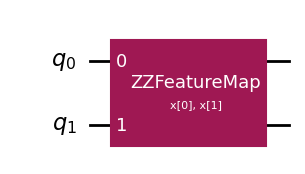

In [8]:
ZZFeatureMap(feature_dimension = num_features).draw('mpl')

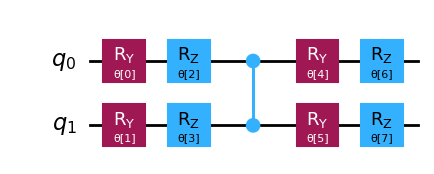

In [9]:
TwoLocal(num_features, ['ry','rz'], 'cz', 'full', reps=1).decompose().draw('mpl')

# Method 1

## Circuit

In [10]:
def qc1(data, variational):

    n = num_features
    
    qreg = QuantumRegister(n,'q')
    qc = QuantumCircuit(qreg)

    enc = ZZFeatureMap(feature_dimension = n)
    
    params0 = enc.parameters
    values0 = data

    enc.assign_parameters(dict(zip(params0, values0)),inplace = True)

    enc_gate = enc.to_gate()
    enc_gate.name = 'Enc'
    
    for i in range(num_reupload):

        var = TwoLocal(n, ['ry','rz'], 'cz', 'full', reps=1)

        params = var.parameters
        values = variational[i*var.num_parameters:(i+1)*var.num_parameters]
        
        var.assign_parameters(dict(zip(params, values)),inplace = True)

        var_gate = var.to_gate()    
        var_gate.name = f'Var{i+1}'
    
        qc.append(enc_gate,qreg)
        qc.append(var_gate,qreg)

    qc.save_statevector(label='sv')

    return qc

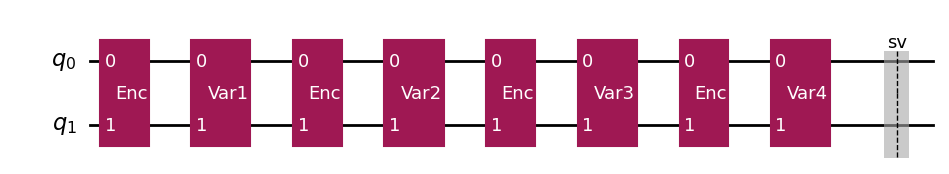

In [11]:
qc1(train_data[0],initial_point).draw('mpl')

## Train Functions

In [12]:
def label_probability_1(state):

    n = num_features
    reduced = partial_trace(state,list(range(1,n)))
    probabilities = reduced.probabilities_dict() 
    
    return probabilities

def classification_probability_1(all_data, variational):

    backend = AerSimulator()
    
    circs = [qc1(d, variational) for d in all_data]
    circs_transpiled = transpile(circs,backend=backend)

    jobs = backend.run(circs_transpiled)
    results = jobs.result()
    
    classification = [
        label_probability_1(results.data(i)['sv']) for i, c in enumerate(circs)]
    
    return classification

def cross_entropy_loss_1(classification, expected):
    """Calculate accuracy of predictions using cross entropy loss.
    Args:
        classification (dict): Dict where keys are possible classes,
                               and values are the probability our
                               circuit chooses that class.
        expected (int): Correct classification of the data point.

    Returns:
        float: Cross entropy loss
    """
    p = classification.get(str(expected))  # Prob. of correct classification
    return -np.log(p)


def cost_function_1(all_data, labels, variational):
    """Evaluates performance of our circuit with `variational`
    parameters on `data`.

    Args:
        data (list): List of data points to classify
        labels (list): List of correct labels for each data point
        variational (list): Parameters to use in circuit

    Returns:
        float: Cost (metric of performance)
    """
    classifications = classification_probability_1(all_data, variational)
    cost = 0
    for i, classification in enumerate(classifications):
        cost += cross_entropy_loss_1(classification, labels[i])
    cost /= len(all_data)
    return cost

def objective_function_1(variational):
    """Cost function of circuit parameters on training data.
    The optimizer will attempt to minimize this."""
    return cost_function_1(train_data, train_labels, variational)

In [13]:
def performance_evaluation(data, labels, variational):
    """Gets classifier's most likely predictions and accuracy of those
    predictions.

    Args:
        data (list): List of data points to classify
        labels (list): List of correct labels for each data point
        variational (list): List of parameter values for classifier

    Returns:
        float: Average accuracy of classifier over `data`
        list: Classifier's label predictions for each data point
    """
    probability = classification_probability_1(data, variational)
    predictions = [0 if p['0'] >= p['1'] else 1 for p in probability]
    accuracy = 0

    for i, prediction in enumerate(predictions):
        if prediction == labels[i]:
            accuracy += 1
    accuracy /= len(labels)
    return accuracy, predictions

## Enhanced OptimizerLog with Result saving

In [14]:
class OptimizerLog:
    """Enhanced optimizer log with automatic result saving"""
    def __init__(self, results_dir):
        self.results_dir = results_dir
        self.evaluations = []
        self.parameters  = []
        self.costs       = []
        self.train_accuracies = []
        self.test_accuracies  = []
        self.stepsizes        = []
        
    def update(self, evaluation, parameter, cost, stepsize, accepted):
        """Update and save intermediate results"""
        self.evaluations.append(evaluation)
        self.parameters.append(parameter.copy())
        self.costs.append(cost)
        self.stepsizes.append(stepsize)
        
        train_accuracy, _ = performance_evaluation(train_data, train_labels, parameter)
        test_accuracy, _  = performance_evaluation(test_data, test_labels, parameter)
        
        self.train_accuracies.append(train_accuracy)
        self.test_accuracies.append(test_accuracy)
        
        if len(self.evaluations) % 1 == 0:
            print(f" Iteration {len(self.evaluations):3d}: Loss = {cost:.4f}, Train Acc = {train_accuracy:0.4f}, Test Acc = {test_accuracy:0.4f}, Step = {stepsize:.4f}")
    
    def save_results(self, final_params, final_cost, optimizer_name):
        """Save final results to JSON and text files"""
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        
        # Final evaluation
        final_train_acc, train_predictions = performance_evaluation(train_data, train_labels, final_params)
        final_test_acc, test_predictions   = performance_evaluation(test_data, test_labels, final_params)
        
        # Prepare results dictionary
        results = {
            "experiment_info": {
                "timestamp": timestamp,
                "optimizer": optimizer_name,
                "dataset": DATASET_NUM,
                "total_iterations": len(self.evaluations)
            },
            "final_results": {
                "final_parameters": final_params.tolist(),
                "final_cost": float(final_cost),
                "final_train_accuracy": float(final_train_acc),
                "final_test_accuracy": float(final_test_acc),
                "train_predictions": train_predictions,
                "test_predictions": test_predictions
            },
            "training_history": {
                "evaluations": self.evaluations,
                "costs": self.costs,
                "train_accuracies": self.train_accuracies,
                "test_accuracies": self.test_accuracies,
                "stepsizes": self.stepsizes,
                "parameters": [p.tolist() for p in self.parameters],
            },
            "data_shapes": {
                "train_data_shape": list(train_data.shape),
                "test_data_shape": list(test_data.shape),
                "train_labels_shape": list(train_labels.shape),
                "test_labels_shape": list(test_labels.shape)
            }
        }
        
        # Save JSON results
        json_filename = os.path.join(self.results_dir, f"results_{optimizer_name.lower()}_{timestamp}.json")
        with open(json_filename, 'w') as f:
            json.dump(results, f, indent=2)
        print(f"Results saved to: {json_filename}")
        
        # Save text summary
        txt_filename = os.path.join(self.results_dir, f"summary_{optimizer_name.lower()}_{timestamp}.txt")
        with open(txt_filename, 'w') as f:
            f.write(f"QML Training Results - {optimizer_name}\n")
            f.write(f"Dataset: {DATASET_NUM}\n")
            f.write(f"Timestamp: {timestamp}\n")
            f.write(f"Total Iterations: {len(self.evaluations)}\n")
            f.write(f"\nFinal Results:\n")
            f.write(f"  Final Cost: {final_cost:.6f}\n")
            f.write(f"  Final Train Accuracy: {final_train_acc:.4f}\n")
            f.write(f"  Final Test Accuracy: {final_test_acc:.4f}\n")
            f.write(f"\nBest Accuracies During Training:\n")
            f.write(f"  Best Train Accuracy: {max(self.train_accuracies):.4f}\n")
            f.write(f"  Best Test Accuracy: {max(self.test_accuracies):.4f}\n")
            f.write(f"  Lowest Cost: {min(self.costs):.6f}\n")
        print(f"Summary saved to: {txt_filename}")
        
        return results

In [15]:
# Method 1 Training with SPSA
print("Starting Method 1 (SPSA) Training...")
log_1 = OptimizerLog(results_dir=RESULTS_DIR)
optimizer_1 = SPSA(maxiter=200, callback=log_1.update)
result_1    = optimizer_1.minimize(objective_function_1, initial_point)

opt_var_1 = result_1.x
opt_value_1 = result_1.fun

print(f"\nOptimization completed!")
print(f"Final cost: {opt_value_1:.6f}")
print(f"Final parameters (first 5): {opt_var_1[:5]}")

Starting Method 1 (SPSA) Training...
 Iteration   1: Loss = 0.7878, Train Acc = 0.5312, Test Acc = 0.4531, Step = 5.3155
 Iteration   2: Loss = 0.7848, Train Acc = 0.4844, Test Acc = 0.5000, Step = 0.6883
 Iteration   3: Loss = 0.8235, Train Acc = 0.5312, Test Acc = 0.3281, Step = 2.1058
 Iteration   4: Loss = 0.7816, Train Acc = 0.4531, Test Acc = 0.4688, Step = 3.3417
 Iteration   5: Loss = 0.7867, Train Acc = 0.4766, Test Acc = 0.4531, Step = 0.8465
 Iteration   6: Loss = 0.7855, Train Acc = 0.5156, Test Acc = 0.4375, Step = 0.2874
 Iteration   7: Loss = 0.8092, Train Acc = 0.5234, Test Acc = 0.4531, Step = 1.3532
 Iteration   8: Loss = 0.8057, Train Acc = 0.5312, Test Acc = 0.4688, Step = 0.3225
 Iteration   9: Loss = 0.8005, Train Acc = 0.5234, Test Acc = 0.4844, Step = 0.4996
 Iteration  10: Loss = 0.8001, Train Acc = 0.5234, Test Acc = 0.4844, Step = 0.0248
 Iteration  11: Loss = 0.7530, Train Acc = 0.5312, Test Acc = 0.5469, Step = 0.8052
 Iteration  12: Loss = 0.7672, Train Ac

In [16]:
results_1 = log_1.save_results(opt_var_1, opt_value_1, "SPSA_Method1")

Results saved to: results/circles_dataset1/results_spsa_method1_20250812_212212.json
Summary saved to: results/circles_dataset1/summary_spsa_method1_20250812_212212.txt


## Generate and save plots

Training progress plot saved to: results/circles_dataset1/training_progress_spsa_20250812_212235.png


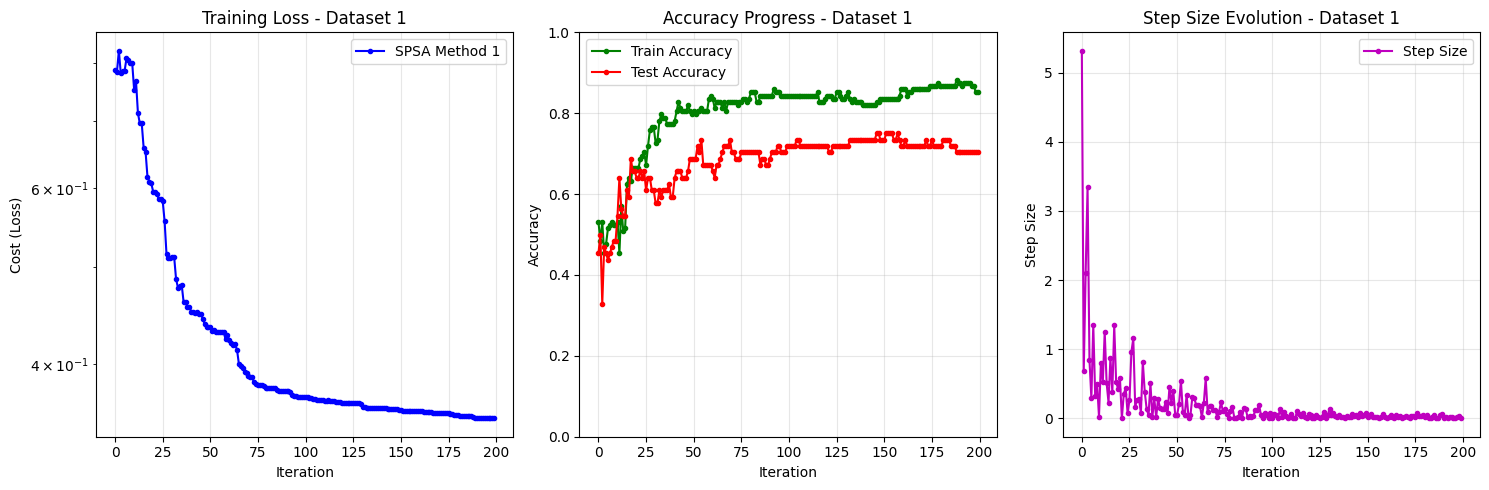

In [17]:
# Plot training progress
plt.figure(figsize=(15, 5))

# Cost plot
plt.subplot(1, 3, 1)
plt.plot(log_1.costs, 'b-o', markersize=3, label='SPSA Method 1')
plt.xlabel('Iteration')
plt.ylabel('Cost (Loss)')
plt.title(f'Training Loss - Dataset {DATASET_NUM}')
plt.grid(True, alpha=0.3)
plt.legend()
plt.yscale('log')

# Accuracy plots
plt.subplot(1, 3, 2)
plt.plot(log_1.train_accuracies, 'g-o', markersize=3, label='Train Accuracy')
plt.plot(log_1.test_accuracies, 'r-o', markersize=3, label='Test Accuracy')
plt.xlabel('Iteration')
plt.ylabel('Accuracy')
plt.title(f'Accuracy Progress - Dataset {DATASET_NUM}')
plt.grid(True, alpha=0.3)
plt.legend()
plt.ylim(0, 1)

# Step size plot
plt.subplot(1, 3, 3)
plt.plot(log_1.stepsizes, 'm-o', markersize=3, label='Step Size')
plt.xlabel('Iteration')
plt.ylabel('Step Size')
plt.title(f'Step Size Evolution - Dataset {DATASET_NUM}')
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()

# Save plot
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
plot_filename = os.path.join(RESULTS_DIR, f"training_progress_spsa_{timestamp}.png")
plt.savefig(plot_filename, dpi=300, bbox_inches='tight')
print(f"Training progress plot saved to: {plot_filename}")
plt.show()

Parameter evolution plot saved to: results/circles_dataset1/parameter_evolution_spsa_20250812_212235.png


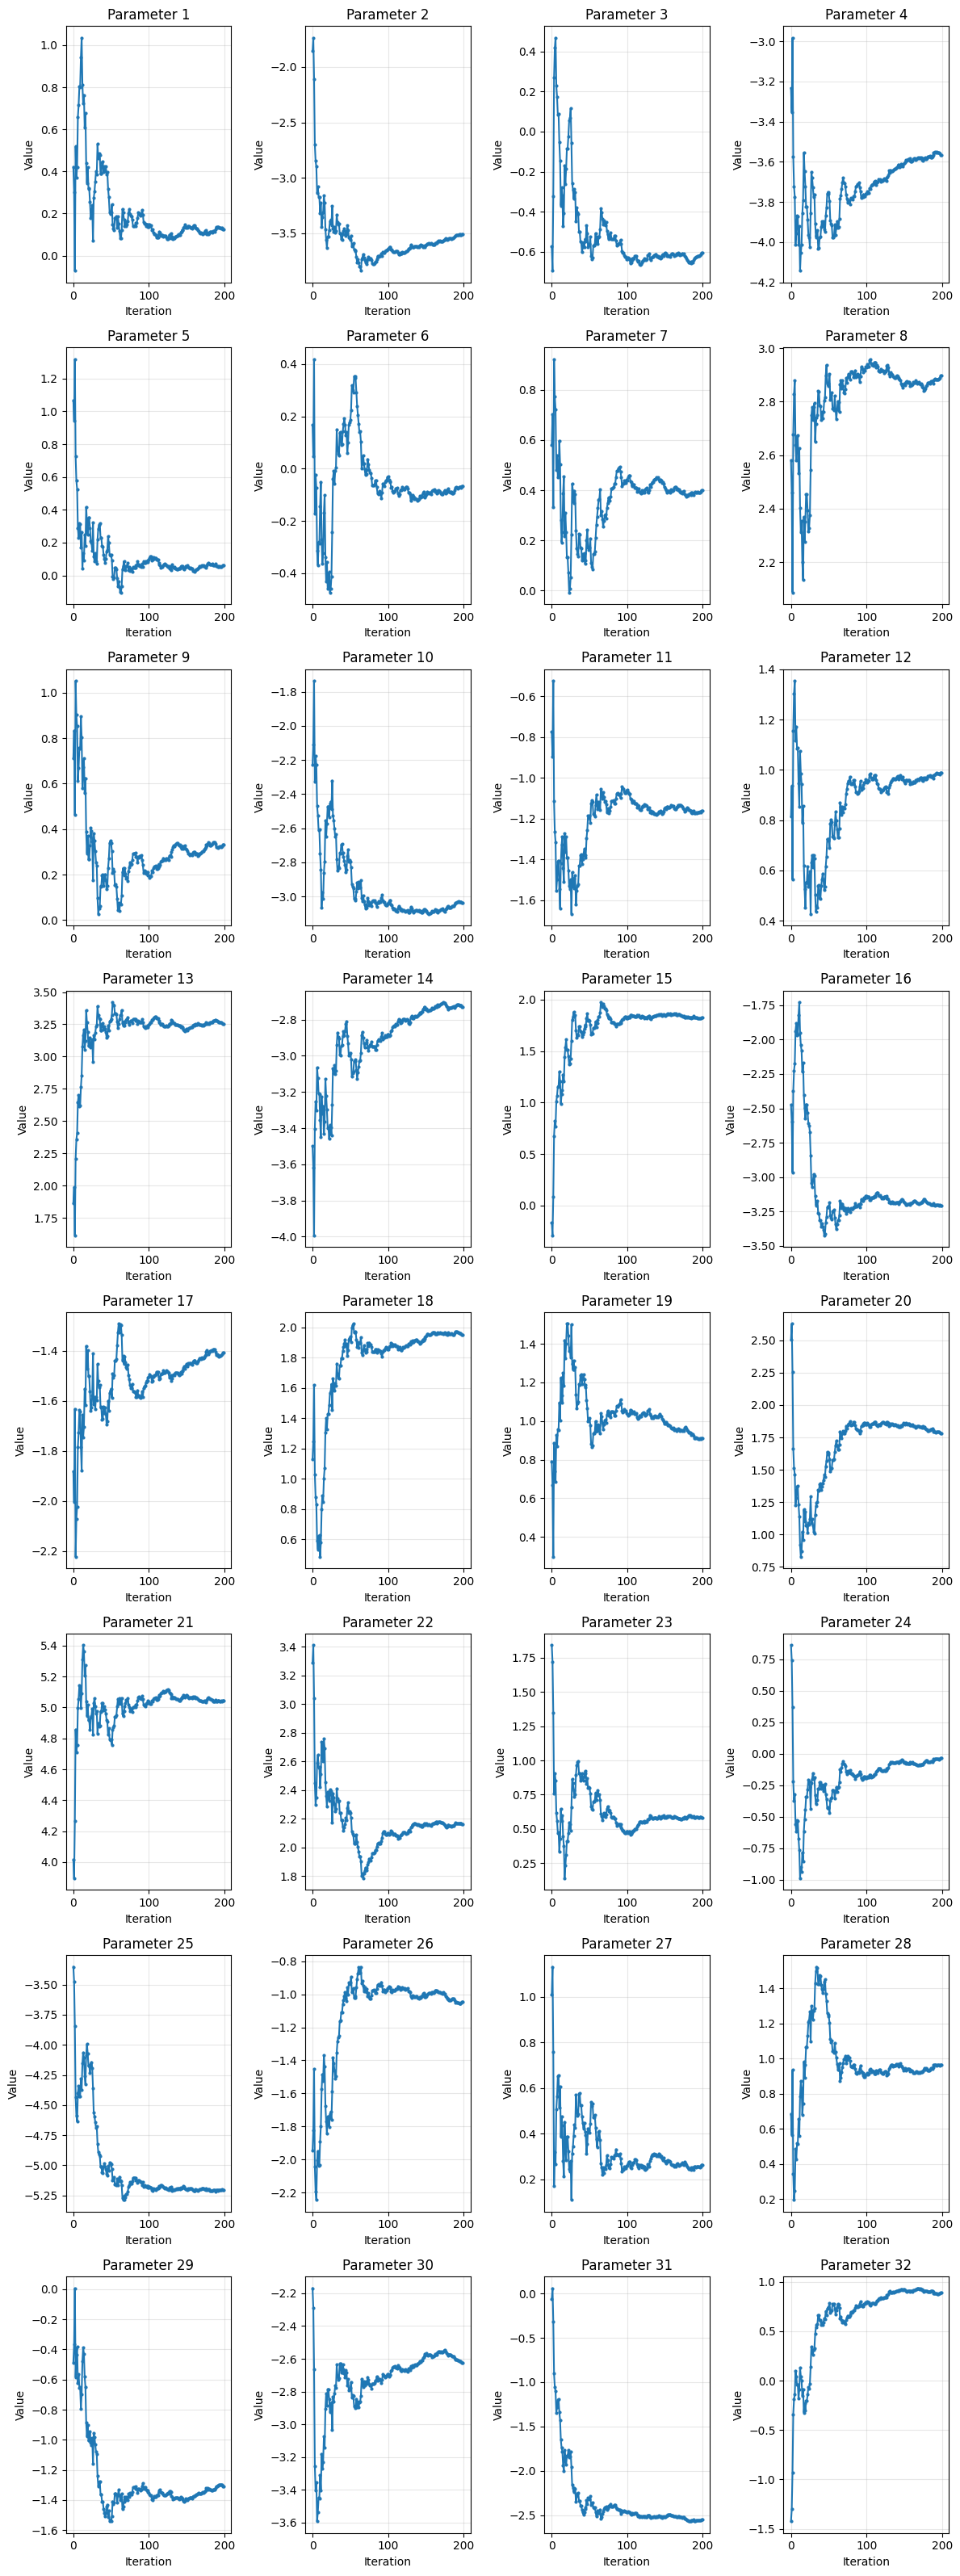

In [18]:
# Parameter evolution plot
if len(log_1.parameters) > 0:
    plt.figure(figsize=(12, 32))
    params_array = np.array(log_1.parameters)
    
    # Plot all parameters
    for i in range(min(32, params_array.shape[1])):
        plt.subplot(8, 4, i+1)
        plt.plot(params_array[:, i], 'o-', markersize=2)
        plt.title(f'Parameter {i+1}')
        plt.grid(True, alpha=0.3)
        plt.xlabel('Iteration')
        plt.ylabel('Value')
    
    plt.tight_layout()
    param_plot_filename = os.path.join(RESULTS_DIR, f"parameter_evolution_spsa_{timestamp}.png")
    plt.savefig(param_plot_filename, dpi=300, bbox_inches='tight')
    print(f"Parameter evolution plot saved to: {param_plot_filename}")
    plt.show()

## Final Performance Analysis

In [19]:
# Final performance evaluation
final_train_acc, train_pred = performance_evaluation(train_data, train_labels, opt_var_1)
final_test_acc, test_pred   = performance_evaluation(test_data, test_labels, opt_var_1)

print(f"\n=== Final Performance Analysis - Dataset {DATASET_NUM} (SPSA) ===")
print(f"Final Training Accuracy: {final_train_acc:.4f}")
print(f"Final Test Accuracy: {final_test_acc:.4f}")
print(f"Final Cost: {opt_value_1:.6f}")
print(f"\nTraining completed successfully!")
print(f"All results saved in: {RESULTS_DIR}")


=== Final Performance Analysis - Dataset 1 (SPSA) ===
Final Training Accuracy: 0.8516
Final Test Accuracy: 0.7031
Final Cost: 0.352810

Training completed successfully!
All results saved in: results/circles_dataset1


# Method 2

## Circuit

In [20]:
def qc2(all_data, variational):
    
    n1 = num_register
    n2 = num_features
    n = n1 + n2
    
    qreg_1 = QuantumRegister(n1,'r')
    qreg_2 = QuantumRegister(n2,'q')
    qreg_3 = QuantumRegister(1,'l')
    
    qc = QuantumCircuit(qreg_1,qreg_2,qreg_3)

    qc.h(qreg_1)
    qc.barrier()
    
    enc = QuantumCircuit(n1+n2)
    
    for i in range(len(all_data)):        
        fm = ZZFeatureMap(feature_dimension=n2)
        params0 = fm.parameters
        values0 = all_data[i]
        fm.assign_parameters(dict(zip(params0, values0)),inplace = True)
        fm_gate = fm.to_gate(label="ZZMap") 
        enc.append(fm_gate.control(num_ctrl_qubits=n1, ctrl_state=format(i, f'0{n1}b')),range(n1+n2))

    enc_gate = enc.to_gate()
    enc_gate.name = 'Enc'

    for i in range(num_reupload):
        
        var = TwoLocal(n2, ['ry','rz'], 'cz', 'full', reps=1)
    
        params = var.parameters
        values = variational[i*var.num_parameters:(i+1)*var.num_parameters]
        
        var.assign_parameters(dict(zip(params, values)),inplace = True)
    
        var_gate = var.to_gate()    
        var_gate.name = f'Var{i+1}'
    
        qc.append(enc_gate,range(n1+n2))
        qc.append(var_gate,range(n1,n1+n2))
         
    qc.save_statevector(label='sv0')
    
    qc.append(XGate().control(num_ctrl_qubits=2, ctrl_state='00'),[n1-1,n1,n1+n2])
    qc.append(XGate().control(num_ctrl_qubits=2, ctrl_state='11'),[n1-1,n1,n1+n2])
   
    qc.save_statevector(label='sv')
    
    return qc

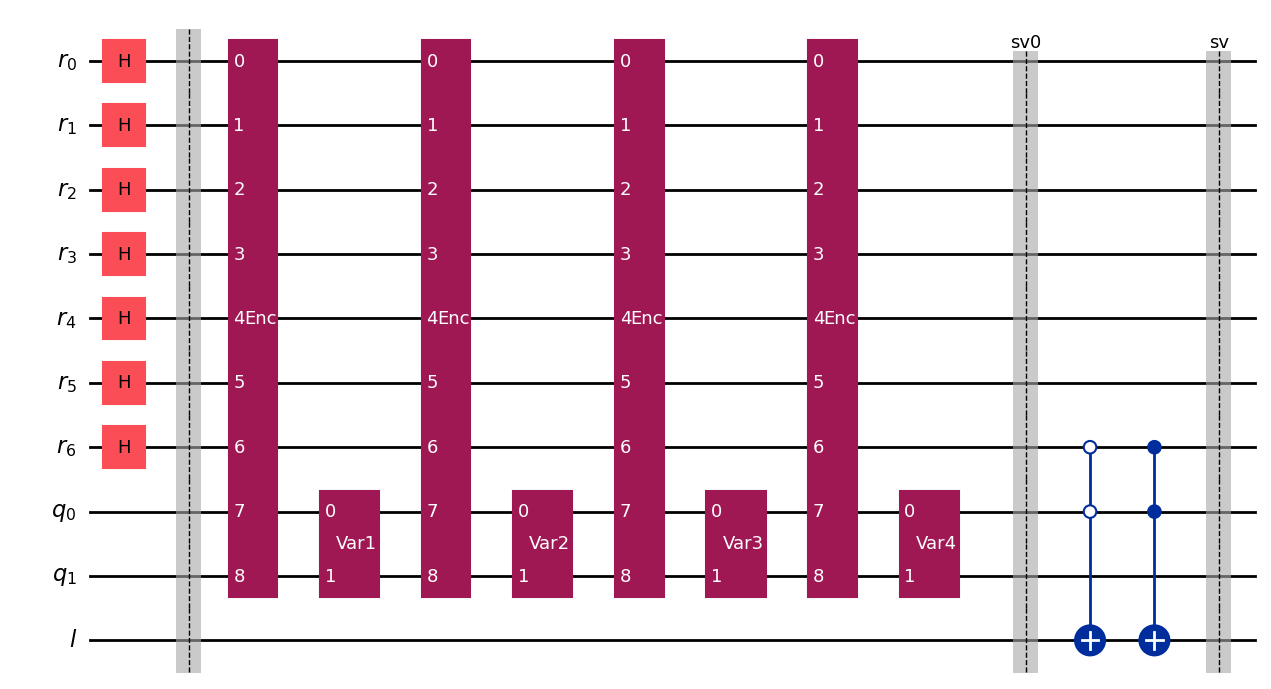

In [21]:
qc2(train_data,initial_point).draw('mpl')

## Train Functions

In [22]:
def label_probability_2(state):

    n = num_register + num_features
    
    reduced = partial_trace(state,list(range(0,n)))
    probabilities = reduced.probabilities_dict()
    
    return probabilities

def classification_probability_2(all_data, variational):

    backend = AerSimulator(device='GPU')
    
    circ = qc2(all_data, variational)
    circ_transpiled = transpile(circ,backend=backend)

    jobs = backend.run(circ_transpiled)
    results = jobs.result()
    
    classification = label_probability_2(results.data()['sv'])
        
    return classification

def cross_entropy_loss_2(classification):
    """Calculate accuracy of predictions using cross entropy loss.
    Args:
        classification (dict): Dict where keys are possible classes,
                               and values are the probability our
                               circuit chooses that class.
        expected (int): Correct classification of the data point.

    Returns:
        float: Cross entropy loss
    """
    p = classification.get('1')  # Prob. of correct classification
    return -np.log(p)


def cost_function_2(all_data, variational):
    """Evaluates performance of our circuit with `variational`
    parameters on `data`.

    Args:
        data (list): List of data points to classify
        labels (list): List of correct labels for each data point
        variational (list): Parameters to use in circuit

    Returns:
        float: Cost (metric of performance)
    """
    classification = classification_probability_2(all_data, variational)
    cost = cross_entropy_loss_2(classification)
    
    return cost


def objective_function_2(variational):
    """Cost function of circuit parameters on training data.
    The optimizer will attempt to minimize this."""
    return cost_function_2(train_data, variational)

## Train

In [23]:
# Method 2 Training with SPSA
print("Starting Method 2 (SPSA) Training...")
log_2       = OptimizerLog( results_dir = RESULTS_DIR)
optimizer_2 = SPSA(maxiter=200, callback=log_2.update)
result_2    = optimizer_2.minimize(objective_function_2, initial_point)

opt_var_2   = result_2.x
opt_value_2 = result_2.fun

print(f"\nMethod 2 Optimization completed!")
print(f"Final cost: {opt_value_2:.6f}")
print(f"Final parameters (first 5): {opt_var_2[:5]}")

Starting Method 2 (SPSA) Training...
 Iteration   1: Loss = 0.5785, Train Acc = 0.6094, Test Acc = 0.6406, Step = 4.9535
 Iteration   2: Loss = 0.5810, Train Acc = 0.6016, Test Acc = 0.6406, Step = 0.4998
 Iteration   3: Loss = 0.5612, Train Acc = 0.6094, Test Acc = 0.5781, Step = 1.5105
 Iteration   4: Loss = 0.5610, Train Acc = 0.6094, Test Acc = 0.5781, Step = 0.0361
 Iteration   5: Loss = 0.5392, Train Acc = 0.5938, Test Acc = 0.6094, Step = 0.8873
 Iteration   6: Loss = 0.5414, Train Acc = 0.6094, Test Acc = 0.6094, Step = 1.2002
 Iteration   7: Loss = 0.5901, Train Acc = 0.5859, Test Acc = 0.5156, Step = 2.0406
 Iteration   8: Loss = 0.5892, Train Acc = 0.5625, Test Acc = 0.5000, Step = 0.1568
 Iteration   9: Loss = 0.5760, Train Acc = 0.5703, Test Acc = 0.5000, Step = 0.4557
 Iteration  10: Loss = 0.5759, Train Acc = 0.5859, Test Acc = 0.5156, Step = 0.1286
 Iteration  11: Loss = 0.5759, Train Acc = 0.6016, Test Acc = 0.5156, Step = 0.0077
 Iteration  12: Loss = 0.5684, Train Ac

In [24]:
# Save Method 2 results
results_2 = log_2.save_results(opt_var_2, opt_value_2, "SPSA_Method2")

Results saved to: results/circles_dataset1/results_spsa_method2_20250813_044204.json
Summary saved to: results/circles_dataset1/summary_spsa_method2_20250813_044204.txt


## Method 2 - Generate and Save Plots

Method 2 training progress plot saved to: results/circles_dataset1/method2_training_progress_spsa_20250813_044214.png


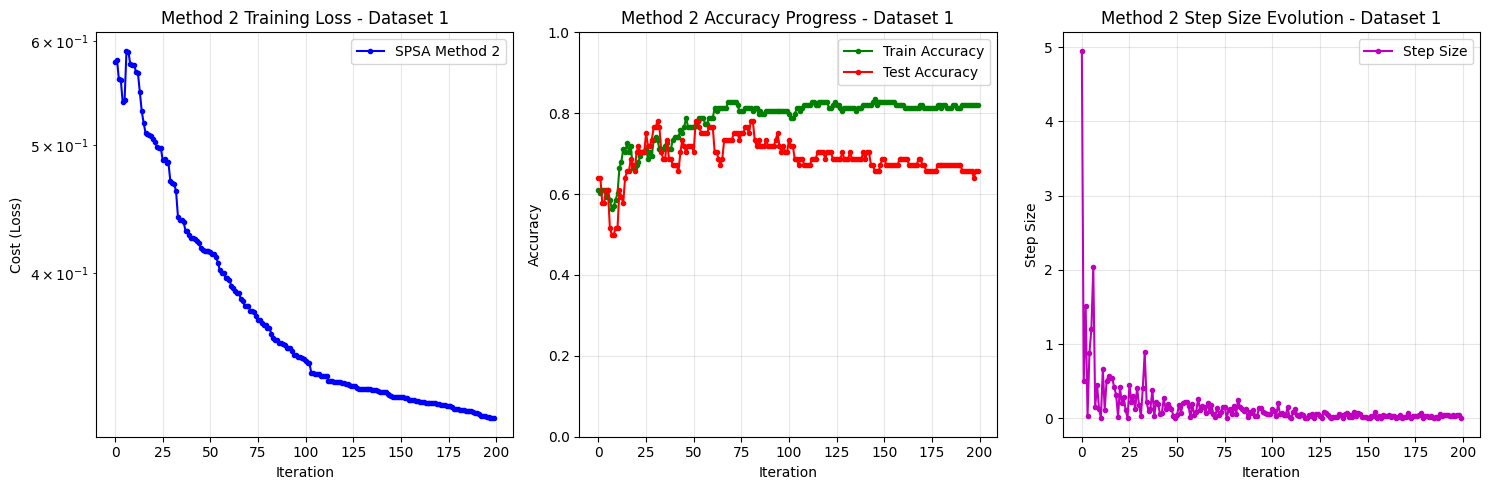

In [25]:
# Method 2 - Plot training progress
plt.figure(figsize=(15, 5))

# Cost plot
plt.subplot(1, 3, 1)
plt.plot(log_2.costs, 'b-o', markersize=3, label='SPSA Method 2')
plt.xlabel('Iteration')
plt.ylabel('Cost (Loss)')
plt.title(f'Method 2 Training Loss - Dataset {DATASET_NUM}')
plt.grid(True, alpha=0.3)
plt.legend()
plt.yscale('log')

# Accuracy plots
plt.subplot(1, 3, 2)
plt.plot(log_2.train_accuracies, 'g-o', markersize=3, label='Train Accuracy')
plt.plot(log_2.test_accuracies, 'r-o', markersize=3, label='Test Accuracy')
plt.xlabel('Iteration')
plt.ylabel('Accuracy')
plt.title(f'Method 2 Accuracy Progress - Dataset {DATASET_NUM}')
plt.grid(True, alpha=0.3)
plt.legend()
plt.ylim(0, 1)

# Step size plot
plt.subplot(1, 3, 3)
plt.plot(log_2.stepsizes, 'm-o', markersize=3, label='Step Size')
plt.xlabel('Iteration')
plt.ylabel('Step Size')
plt.title(f'Method 2 Step Size Evolution - Dataset {DATASET_NUM}')
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()

# Save plot
timestamp_2 = datetime.now().strftime("%Y%m%d_%H%M%S")
plot_filename_2 = os.path.join(RESULTS_DIR, f"method2_training_progress_spsa_{timestamp_2}.png")
plt.savefig(plot_filename_2, dpi=300, bbox_inches='tight')
print(f"Method 2 training progress plot saved to: {plot_filename_2}")
plt.show()

Method 2 parameter evolution plot saved to: results/circles_dataset1/method2_parameter_evolution_spsa_20250813_044214.png


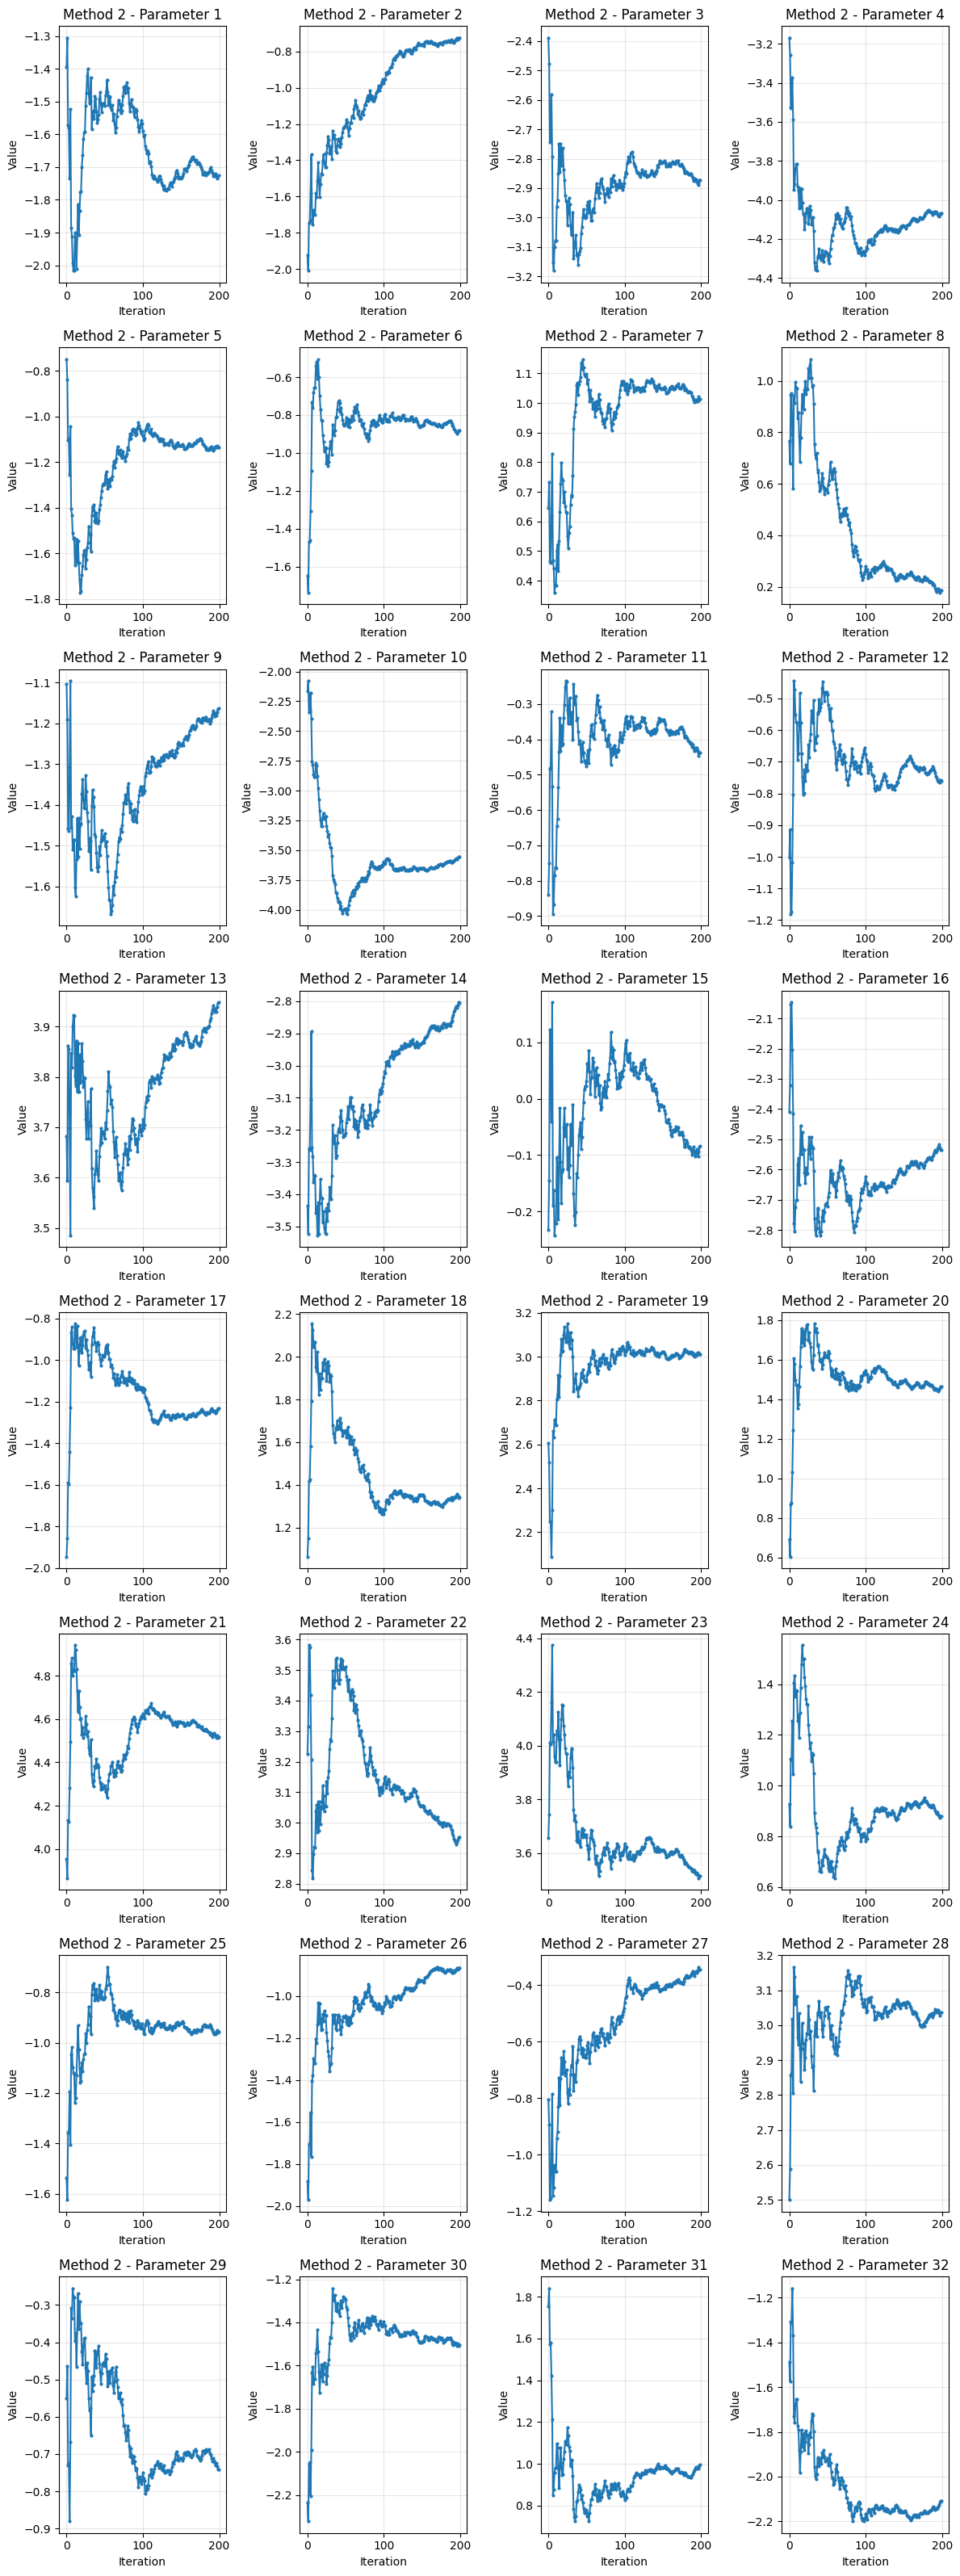

In [26]:
# Method 2 - Parameter evolution plot
if len(log_2.parameters) > 0:
    plt.figure(figsize=(12, 32))
    params_array_2 = np.array(log_2.parameters)
    
    # Plot all parameters
    for i in range(min(32, params_array_2.shape[1])):
        plt.subplot(8, 4, i+1)
        plt.plot(params_array_2[:, i], 'o-', markersize=2)
        plt.title(f'Method 2 - Parameter {i+1}')
        plt.grid(True, alpha=0.3)
        plt.xlabel('Iteration')
        plt.ylabel('Value')
    
    plt.tight_layout()
    param_plot_filename_2 = os.path.join(RESULTS_DIR, f"method2_parameter_evolution_spsa_{timestamp_2}.png")
    plt.savefig(param_plot_filename_2, dpi=300, bbox_inches='tight')
    print(f"Method 2 parameter evolution plot saved to: {param_plot_filename_2}")
    plt.show()

## Method 2 - Final Performance Analysis

In [27]:
# Method 2 - Final performance evaluation
final_train_acc_2, train_pred_2 = performance_evaluation(train_data, train_labels, opt_var_2)
final_test_acc_2, test_pred_2   = performance_evaluation(test_data, test_labels, opt_var_2)

print(f"\n=== Method 2 Final Performance Analysis - Dataset {DATASET_NUM} (SPSA) ===")
print(f"Method 2 Final Training Accuracy: {final_train_acc_2:.4f}")
print(f"Method 2 Final Test Accuracy: {final_test_acc_2:.4f}")
print(f"Method 2 Final Cost: {opt_value_2:.6f}")
print(f"\nMethod 2 Training completed successfully!")
print(f"All Method 2 results saved in: {RESULTS_DIR}")


=== Method 2 Final Performance Analysis - Dataset 1 (SPSA) ===
Method 2 Final Training Accuracy: 0.8203
Method 2 Final Test Accuracy: 0.6562
Method 2 Final Cost: 0.310118

Method 2 Training completed successfully!
All Method 2 results saved in: results/circles_dataset1
